# Bounded Tree-Depth Graphs as a Uniformly Automatic Class

A **uniformly automatic class** presents a whole *family* of structures with a single tuple of automata: every automaton carries one extra tape holding an **advice string** that is read synchronously with the element encodings. Fixing an advice string instantiates one member structure — and a query evaluated once over the class yields an automaton that decides the query for *every* member, just by running its advice string.

`autstr.graphs` implements the classic example: for a fixed bound $d$, the class of all finite graphs of **tree-depth $\le d$**.

* The advice spells out a DFS traversal of an *elimination forest* of height $\le d$: one letter per vertex, encoding its depth and its adjacency profile to its ancestors.
* Elements of the presented structures are **sets of vertices** (encoded as bitvectors over the DFS positions), so first-order logic over the presentation is **monadic second-order logic** over the graph.
* The signature is `Sing(x)` (x is a singleton), `Subset(x,y)`, and `E(x,y)` (x, y are adjacent singletons).

> Variable naming: the nltk formula parser only treats names matching `[a-df-z][0-9]*` as variables — single lowercase letters (except `e`), optionally followed by digits.

In [1]:
import networkx as nx

from autstr.graphs import TreeDepthClass, TreeDepthGraph

## The presentation generator

`TreeDepthClass(d)` builds the uniform presentation for depth bound $d$. Its advice alphabet has one letter per (depth, profile) pair — $2^d - 1$ letters — plus `0`, `1`, `*` for the set encodings and padding.

In [2]:
cls = TreeDepthClass(3)

print("relations:      ", cls.cls.get_relation_symbols())
print("advice alphabet:", sorted(cls.symbol_of.values()))

relations:       ['U', 'Sing', 'Subset', 'E']
advice alphabet: ['a1_', 'a2_0', 'a2_1', 'a3_00', 'a3_01', 'a3_10', 'a3_11']


## From networkx to strings

`TreeDepthGraph.from_networkx` computes an elimination forest (exact minimum height for small graphs, a DFS forest otherwise — you can also pass your own via `forest=`), orders the vertices by DFS, and encodes each vertex as a `(depth, profile)` letter. The graph *is* this string.

In [3]:
P4 = TreeDepthGraph.from_networkx(nx.path_graph(4))

print(P4)
print("DFS order:               ", P4.nodes)
print("letters (depth, profile):", P4.letters)
print("advice string:           ", cls.advice(P4))

TreeDepthGraph(4 nodes, height 3)
DFS order:                [0, 2, 1, 3]
letters (depth, profile): [(1, ()), (2, (0,)), (3, (1, 1)), (3, (0, 1))]
advice string:            ['a1_', 'a2_0', 'a3_11', 'a3_01']


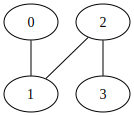

In [4]:
P4.to_graphviz()

## Checking atomic relations

`check(phi, graph, **sets)` assigns concrete vertex sets to the free variables and runs the convolution of the advice with the set encodings through the query automaton.

In [5]:
for u, v in [(0, 1), (0, 2), (1, 2)]:
    print(f"E({{{u}}}, {{{v}}}) =", cls.check('E(x,y)', P4, x={u}, y={v}))

print("Sing({1})          =", cls.check('Sing(x)', P4, x={1}))
print("{0,1} subset {0,1,3} =", cls.check('Subset(x,y)', P4, x={0, 1}, y={0, 1, 3}))

E({0}, {1}) = True
E({0}, {2}) = False
E({1}, {2}) = True
Sing({1})          = True
{0,1} subset {0,1,3} = True


## Uniformity: one automaton decides all member graphs

Evaluating a sentence over the class gives an automaton whose only tape is the advice. Model checking a member graph is then *just running a word through a DFA* — no per-graph computation at all.

In [6]:
has_edge, tapes = cls.evaluate('exists x.(exists y.(E(x,y)))')
print("tapes:", tapes, "| states:", has_edge.num_states)

for name, g in [('empty', nx.empty_graph(3)), ('star', nx.star_graph(2)), ('path', nx.path_graph(4))]:
    advice = cls.advice(TreeDepthGraph.from_networkx(g))
    print(f"{name:>6} graph has an edge: {has_edge.accepts([(s,) for s in advice])}")

tapes: ['advice'] | states: 7
 empty graph has an edge: False
  star graph has an edge: True
  path graph has an edge: True


## MSO: bipartiteness

Because elements are vertex sets, we get genuine monadic second-order queries. Bipartiteness says: *there exists a set $c$ such that every edge crosses the cut $(c, \bar c)$*.

Compiling the query takes a few seconds — **once, for the entire class**. Afterwards each graph is decided in microseconds.

In [7]:
bipartite = ('exists c.(all x.(all y.((not E(x,y)) or '
             '((Subset(x,c) and (not Subset(y,c))) or '
             '((not Subset(x,c)) and Subset(y,c))))))')

%time bip_dfa, _ = cls.evaluate(bipartite)
print("bipartiteness automaton:", bip_dfa.num_states, "states")

CPU times: user 12.2 s, sys: 186 ms, total: 12.4 s
Wall time: 12.4 s
bipartiteness automaton: 6 states


In [8]:
graphs = {
    'triangle':        nx.cycle_graph(3),
    'path P7':         nx.path_graph(7),
    'star K(1,3)':     nx.star_graph(3),
    'triangle + path': nx.disjoint_union(nx.cycle_graph(3), nx.path_graph(3)),
}

for name, g in graphs.items():
    advice = cls.advice(TreeDepthGraph.from_networkx(g))
    %time result = bip_dfa.accepts([(s,) for s in advice])
    print(f"{name:>16}: bipartite = {result}\n")

CPU times: user 68 µs, sys: 2 µs, total: 70 µs
Wall time: 86.3 µs
        triangle: bipartite = False

CPU times: user 38 µs, sys: 0 ns, total: 38 µs
Wall time: 41.7 µs
         path P7: bipartite = True

CPU times: user 26 µs, sys: 0 ns, total: 26 µs
Wall time: 30 µs
     star K(1,3): bipartite = True

CPU times: user 32 µs, sys: 0 ns, total: 32 µs
Wall time: 36 µs
 triangle + path: bipartite = False



## Extracting a witness coloring

Dropping the outer $\exists c$ leaves the *proper 2-coloring* relation with $c$ free: the resulting automaton runs over (advice, $c$) pairs, so we can search for concrete color classes.

In [9]:
coloring = ('all x.(all y.((not E(x,y)) or '
            '((Subset(x,c) and (not Subset(y,c))) or '
            '((not Subset(x,c)) and Subset(y,c)))))')

col_dfa, tapes = cls.evaluate(coloring)
print("tapes:", tapes)

tapes: ['c', 'advice']


In [10]:
from itertools import chain, combinations

advice = cls.advice(P4)

def convolution(color_class):
    columns = {'advice': advice, 'c': P4.encode_set(color_class)}
    return [tuple(columns[t][i] for t in tapes) for i in range(P4.num_nodes)]

subsets = chain.from_iterable(combinations(P4.nodes, r) for r in range(P4.num_nodes + 1))
witnesses = [set(s) for s in subsets if col_dfa.accepts(convolution(set(s)))]
print("valid color classes of the path:", witnesses)

valid color classes of the path: [{0, 2}, {1, 3}]


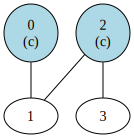

In [11]:
P4.to_graphviz(sets={'c': witnesses[0]})

## A single graph as an ordinary automatic presentation

`get_structure` fixes the advice tape to one graph and projects it away, leaving a plain `AutomaticPresentation` of that graph (over vertex sets, as in MSO0) — usable with the rest of the library.

In [ ]:
S = cls.get_structure(P4)
print("relations:", S.get_relation_symbols())

edge = S.evaluate('E(x,y)')
for u, v in [(0, 1), (0, 3)]:
    word = list(zip(P4.encode_set({u}), P4.encode_set({v})))
    print(f"E({{{u}}}, {{{v}}}) =", edge.accepts(word))

## Round trip

The string representation is lossless: `to_networkx` reconstructs the graph, node names included.

In [ ]:
back = P4.to_networkx()
sorted(back.edges) == sorted(nx.path_graph(4).edges)

---

**Notes.** The construction scales with the depth bound: the advice alphabet has $2^d - 1$ letters, so query compilation grows quickly with $d$ — but it happens once per (class, query), never per graph. The generic machinery behind this lives in `autstr.uniform.UniformlyAutomaticClass`, which turns *any* advice-indexed family of automata into a uniformly automatic class with relativized query evaluation, sentence checking, and member-structure instantiation.